## Exploratory Data Analysis

In [24]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

In [10]:
# read csv
df = pd.read_csv("TSLA_5min_2yr.csv", parse_dates=["timestamp"])
print("rows, cols:", df.shape)
df.head()

rows, cols: (81536, 9)


,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,TSLA,2024-02-28 16:50:00+00:00,204.0080,204.5200,203.9300,204.4720,825405,7429,204.258681
1,TSLA,2024-02-28 16:55:00+00:00,204.4800,204.5500,203.9200,204.2700,890920,8171,204.240494
2,TSLA,2024-02-28 17:00:00+00:00,204.2881,204.3000,203.7601,204.0800,852368,8128,204.026026
3,TSLA,2024-02-28 17:05:00+00:00,204.0900,204.1433,203.3100,203.4000,1179708,10959,203.606468
4,TSLA,2024-02-28 17:10:00+00:00,203.4050,203.6000,203.0300,203.4391,1141511,9367,203.319139


In [11]:
df.dtypes

symbol                      object
timestamp      datetime64[ns, UTC]
open                       float64
high                       float64
low                        float64
close                      float64
volume                       int64
trade_count                  int64
vwap                       float64
dtype: object

In [12]:
# set variables

# I want only active trading hours 9:30 - 4PM Eastern Time
REGULAR_SESSION_ONLY = True
TZ_LOCAL = "America/New_York"

df = df.copy()

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
bad_ts = df["timestamp"].isna().sum()
if bad_ts:
    print("WARNING: bad timestamps:", bad_ts)

# convert to eastern time
df["ts_ny"] = df["timestamp"].dt.tz_convert(TZ_LOCAL)

# ensure we don't have duplicates
df = df.sort_values(["timestamp"]).reset_index(drop=True)

dup = df.duplicated(subset=["timestamp"]).sum()
print("duplicate timestamps:", dup)
if dup:
    df = df.drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

# filter for active trading hours 9:30 - 16:00
df["date_ny"] = df["ts_ny"].dt.date
df["time_ny"] = df["ts_ny"].dt.time

if REGULAR_SESSION_ONLY:
    # 9:30 <= time < 16:00
    mask = (df["ts_ny"].dt.hour > 9) | ((df["ts_ny"].dt.hour == 9) & (df["ts_ny"].dt.minute >= 30))
    mask &= (df["ts_ny"].dt.hour < 16)
    before = len(df)
    df = df.loc[mask].reset_index(drop=True)
    print(f"regular session rows kept: {len(df)} / {before}")

deltas = df["timestamp"].diff().dropna()
vc = deltas.value_counts().head(5)
print("Top time deltas:")
print(vc)

print("min timestamp:", df["timestamp"].min())
print("max timestamp:", df["timestamp"].max())
print(df.head(3)[["symbol","timestamp","ts_ny","open","high","low","close","volume"]])
print(df.tail(3)[["symbol","timestamp","ts_ny","open","high","low","close","volume"]])

duplicate timestamps: 0
regular session rows kept: 33310 / 81536
Top time deltas:
timestamp
0 days 00:05:00    32878
0 days 17:35:00      326
2 days 17:35:00       75
1 days 17:35:00       10
3 days 17:35:00        8
Name: count, dtype: int64
min timestamp: 2024-02-28 16:50:00+00:00
max timestamp: 2026-02-27 16:45:00+00:00
  symbol                 timestamp                     ts_ny      open  \
0   TSLA 2024-02-28 16:50:00+00:00 2024-02-28 11:50:00-05:00  204.0080   
1   TSLA 2024-02-28 16:55:00+00:00 2024-02-28 11:55:00-05:00  204.4800   
2   TSLA 2024-02-28 17:00:00+00:00 2024-02-28 12:00:00-05:00  204.2881   

     high       low    close  volume  
0  204.52  203.9300  204.472  825405  
1  204.55  203.9200  204.270  890920  
2  204.30  203.7601  204.080  852368  
      symbol                 timestamp                     ts_ny    open  \
33307   TSLA 2026-02-27 16:35:00+00:00 2026-02-27 11:35:00-05:00  403.43   
33308   TSLA 2026-02-27 16:40:00+00:00 2026-02-27 11:40:00-05:00  402.

In [14]:
# check if we have all price action for each day
day_coverage = (
    df.groupby("date_ny")["ts_ny"]
      .agg(first="min", last="max", bars="count")
      .reset_index()
)

print(day_coverage.head(5))
print(day_coverage.tail(5))

#check to see if we have all of the 5 minute price records for a day
print("Days with >= 75 bars:", (day_coverage["bars"] >= 75).sum(), "out of", len(day_coverage))

      date_ny                     first                      last  bars
0  2024-02-28 2024-02-28 11:50:00-05:00 2024-02-28 15:55:00-05:00    50
1  2024-02-29 2024-02-29 09:30:00-05:00 2024-02-29 15:55:00-05:00    78
2  2024-03-01 2024-03-01 09:30:00-05:00 2024-03-01 15:55:00-05:00    78
3  2024-03-04 2024-03-04 09:30:00-05:00 2024-03-04 15:55:00-05:00    78
4  2024-03-05 2024-03-05 09:30:00-05:00 2024-03-05 15:55:00-05:00    78
        date_ny                     first                      last  bars
427  2026-02-23 2026-02-23 09:30:00-05:00 2026-02-23 15:55:00-05:00    78
428  2026-02-24 2026-02-24 09:30:00-05:00 2026-02-24 15:55:00-05:00    78
429  2026-02-25 2026-02-25 09:30:00-05:00 2026-02-25 15:55:00-05:00    78
430  2026-02-26 2026-02-26 09:30:00-05:00 2026-02-26 15:55:00-05:00    78
431  2026-02-27 2026-02-27 09:30:00-05:00 2026-02-27 11:45:00-05:00    28
Days with >= 75 bars: 420 out of 432


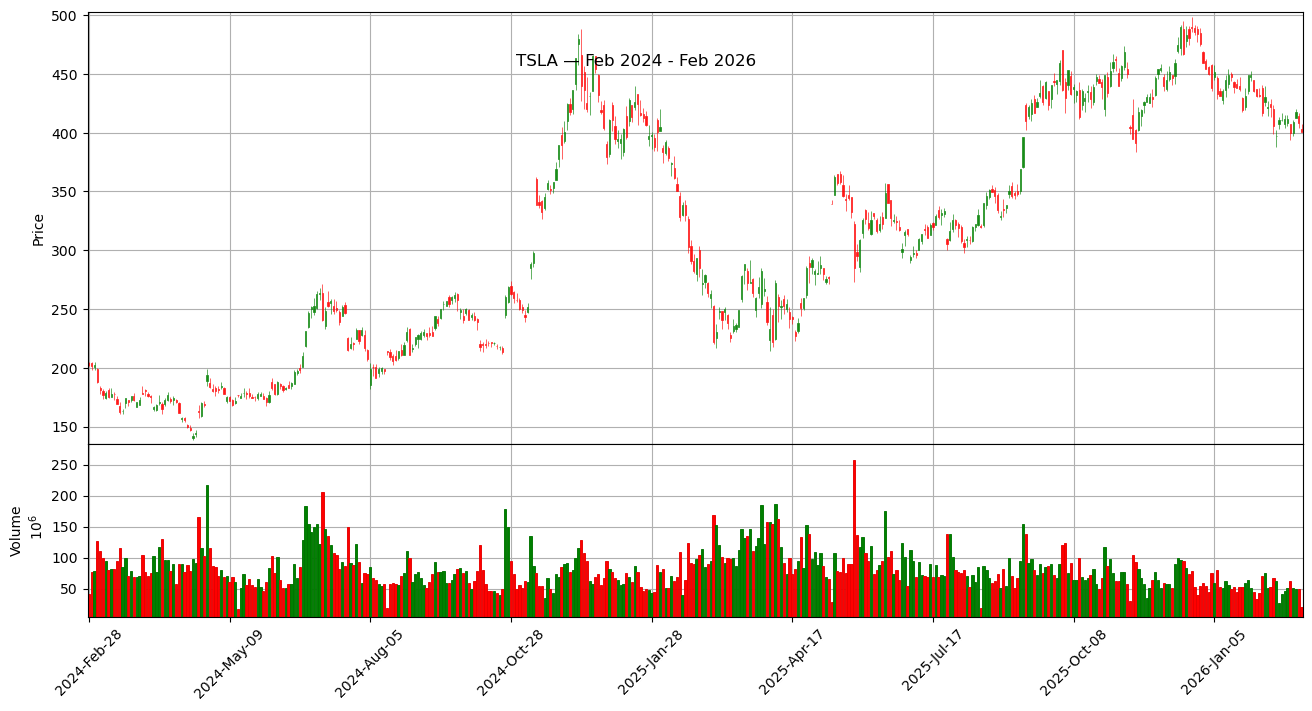

In [27]:
# visualize TSLA Daily Chart
df_ = df.copy()
df_["ts_ny"] = pd.to_datetime(df_["ts_ny"])
df_ = df_.set_index("ts_ny").sort_index()

daily = df_.resample("1D").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
}).dropna()

mc = mpf.make_marketcolors(
    up='green',
    down='red',
    edge='inherit',
    wick='inherit',
    volume='inherit'
)

style = mpf.make_mpf_style(
    marketcolors=mc,
    gridstyle='-'
)

mpf.plot(
    daily,
    type="candle",
    volume=True,
    style=style,
    title="TSLA — Feb 2024 - Feb 2026",
    ylabel="Price",
    ylabel_lower="Volume",
    figsize=(14, 7),
    tight_layout=True
)

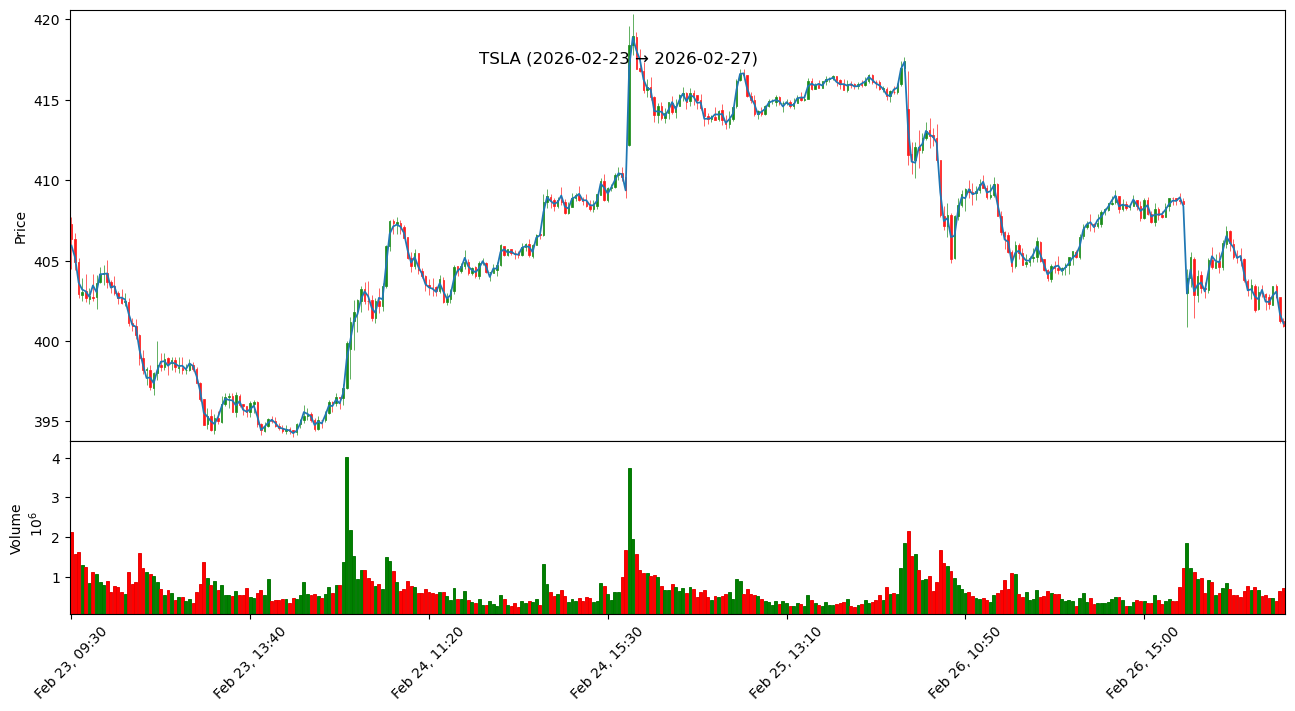

In [29]:
# visualize last 5 trading days
last_5_dates = sorted(df["date_ny"].unique())[-5:]
df5 = df[df["date_ny"].isin(last_5_dates)].copy()

df5["ts_ny"] = pd.to_datetime(df5["ts_ny"])
df5 = df5.set_index("ts_ny").sort_index()

plot_df = df5.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume",
})

mc = mpf.make_marketcolors(
    up="green",
    down="red",
    edge="inherit",
    wick="inherit",
    volume="inherit"
)
style = mpf.make_mpf_style(marketcolors=mc)

apds = [
    mpf.make_addplot(df5["vwap"], panel=0)
]

mpf.plot(
    plot_df,
    type="candle",
    volume=True,
    addplot=apds,
    style=style,
    title=f"TSLA ({last_5_dates[0]} → {last_5_dates[-1]})",
    ylabel="Price",
    ylabel_lower="Volume",
    figsize=(14, 7),
    tight_layout=True
)

## Feature Engineering

We will calculate price action indicators in preparation for generating entry and exits

The indicators we'll use are:
- VWAP
- ATR / Volatility
- Returns
- Range
- Volume Impulse
- Time of Day

In [31]:
df = df.sort_values("timestamp").reset_index(drop=True)

# calculate session VWAP
tp = (df["high"] + df["low"] + df["close"]) / 3.0
pv = tp * df["volume"]
df["vwap_session"] = (
    pv.groupby(df["date_ny"]).cumsum()
    / df["volume"].groupby(df["date_ny"]).cumsum()
)

# ATR
prev_close = df["close"].shift(1)
tr = pd.concat(
    [
        (df["high"] - df["low"]).abs(),
        (df["high"] - prev_close).abs(),
        (df["low"] - prev_close).abs(),
    ],
    axis=1,
).max(axis=1)

df["atr_14"] = tr.rolling(14, min_periods=14).mean()
df["atr_pct_14"] = df["atr_14"] / df["close"]

# Returns
df["ret_1"] = np.log(df["close"] / df["close"].shift(1))
df["ret_3"] = np.log(df["close"] / df["close"].shift(3))
df["ret_6"] = np.log(df["close"] / df["close"].shift(6))

# Range
df["range_pct"] = (df["high"] - df["low"]) / df["close"]
df["body_pct"] = (df["close"] - df["open"]).abs() / df["close"]
df["upper_wick_pct"] = (df["high"] - df[["open", "close"]].max(axis=1)) / df["close"]
df["lower_wick_pct"] = (df[["open", "close"]].min(axis=1) - df["low"]) / df["close"]

# VWAP distance
df["vwap_dist"] = (df["close"] - df["vwap_session"]) / df["close"]
df["vwap_dist_atr"] = (df["close"] - df["vwap_session"]) / df["atr_14"]

# Volume impulse
vol_ma20 = df["volume"].rolling(20, min_periods=20).mean()
df["vol_ratio_20"] = df["volume"] / vol_ma20

# Realized volatility proxy
df["rv_12"] = df["ret_1"].rolling(12, min_periods=12).std()

# Time of Day
minutes = df["ts_ny"].dt.hour * 60 + df["ts_ny"].dt.minute
session_start = 9 * 60 + 30
x = (minutes - session_start) / 390.0
df["tod_sin"] = np.sin(2 * np.pi * x)
df["tod_cos"] = np.cos(2 * np.pi * x)

In [33]:
feature_cols = [
    "vwap_session","atr_14","atr_pct_14",
    "ret_1","ret_3","ret_6",
    "range_pct","body_pct","upper_wick_pct","lower_wick_pct",
    "vwap_dist","vwap_dist_atr",
    "vol_ratio_20","rv_12",
    "tod_sin","tod_cos"
]

print("NaNs")
print(df[feature_cols].isna().sum().sort_values(ascending=False).head(10))

print("\nFeature preview:")
print(df[["ts_ny","close","vwap_session","atr_14","vol_ratio_20","vwap_dist_atr","ret_1"]].tail(25))

NaNs
vol_ratio_20     19
atr_14           13
atr_pct_14       13
vwap_dist_atr    13
rv_12            12
ret_6             6
ret_3             3
ret_1             1
vwap_session      0
range_pct         0
dtype: int64

Feature preview:
                          ts_ny     close  vwap_session    atr_14  \
33285 2026-02-27 09:45:00-05:00  404.0650    403.590094  1.648307   
33286 2026-02-27 09:50:00-05:00  403.2800    403.581564  1.689021   
33287 2026-02-27 09:55:00-05:00  403.2050    403.544900  1.659021   
33288 2026-02-27 10:00:00-05:00  405.0095    403.646387  1.754029   
33289 2026-02-27 10:05:00-05:00  404.5700    403.779160  1.815814   
33290 2026-02-27 10:10:00-05:00  404.9000    403.848636  1.814379   
33291 2026-02-27 10:15:00-05:00  404.6100    403.906421  1.854029   
33292 2026-02-27 10:20:00-05:00  406.0700    404.023730  1.952600   
33293 2026-02-27 10:25:00-05:00  406.8540    404.217449  2.014743   
33294 2026-02-27 10:30:00-05:00  406.0750    404.334456  2.060457   
33295

Indicators with NaNs are expecting since they need rolling price data to be calculated

### Entry Opportunities

We want to create entry signals based on a setup I used often (VWAP Reclaim)

Entry Signal:
- Long entry when price is below VWAP on the prior 5M bar and closes above VWAP on current bar
- We use volume as an indicator if price will continue to sustain upon reclaiming VWAP

In [34]:
# VWAP Reclaim setup signal

VOL_IMPULSE = 1.5

signal = (
    (df["close"].shift(1) < df["vwap_session"].shift(1)) &
    (df["close"] > df["vwap_session"]) &
    (df["vol_ratio_20"] >= VOL_IMPULSE) &
    (df["ret_1"] > 0)
)

signal_idx = np.flatnonzero(signal.values)
entry_idx = signal_idx + 1

entry_idx = entry_idx[entry_idx < len(df)]
signal_idx = signal_idx[:len(entry_idx)]

entries = pd.DataFrame({
    "i_signal": signal_idx,
    "i_entry": entry_idx,
    "ts_signal": df.loc[signal_idx, "ts_ny"].values,
    "ts_entry": df.loc[entry_idx, "ts_ny"].values,
    "entry_price": df.loc[entry_idx, "open"].values,
})

needed_signal = ["atr_14", "vol_ratio_20", "vwap_session", "ret_1"]
needed_entry = ["atr_14"]

ok_signal = df.loc[entries["i_signal"], needed_signal].notna().all(axis=1).values
ok_entry = df.loc[entries["i_entry"], needed_entry].notna().all(axis=1).values

entries = entries.loc[ok_signal & ok_entry].reset_index(drop=True)

print("Total entries found:", len(entries))
print(entries.head(10))

Total entries found: 336
   i_signal  i_entry           ts_signal            ts_entry  entry_price
0        51       52 2024-02-29 14:35:00 2024-02-29 14:40:00     204.1900
1       126      127 2024-02-29 20:50:00 2024-02-29 20:55:00     201.9000
2       131      132 2024-03-01 14:45:00 2024-03-01 14:50:00     199.9500
3       440      441 2024-03-07 14:30:00 2024-03-07 14:35:00     178.1071
4       520      521 2024-03-08 14:40:00 2024-03-08 14:45:00     180.7900
5       596      597 2024-03-11 13:30:00 2024-03-11 13:35:00     177.0059
6       755      756 2024-03-13 13:45:00 2024-03-13 13:50:00     174.2700
7       830      831 2024-03-14 13:30:00 2024-03-14 13:35:00     171.0500
8       908      909 2024-03-15 13:30:00 2024-03-15 13:35:00     164.8700
9       984      985 2024-03-15 19:50:00 2024-03-15 19:55:00     163.5500


### Trade Simulator and Labeling

We want to Identify these trades and label them for use later. We want to simulate multiple realistic parameter combinations for supervised learning targets. This will help the model learn how market conditions at entry influence execution settings.

We will evaluate 36 parameter combinations with varying stop sizes, target sizes, and max hold times. We'll simulate the trades and label for model use.

In [37]:
# stops, targets, and hold times
stops = [0.5, 0.75, 1.0]
targets = [0.75, 1.0, 1.5, 2.0]
holds = [6, 12, 24] 

grid = [(s, t, h) for s in stops for t in targets for h in holds]
print("Grid size:", len(grid))

def simulate_one_entry_long(df, i_entry, stop_atr, target_atr, hold_bars):
    entry_price = float(df.at[i_entry, "open"])
    atr = df.at[i_entry, "atr_14"]
    if pd.isna(atr) or atr <= 0:
        return None

    atr = float(atr)
    risk = stop_atr * atr
    stop_price = entry_price - risk
    target_price = entry_price + target_atr * atr

    i_end = min(i_entry + hold_bars - 1, len(df) - 1)
    window = df.loc[i_entry:i_end, ["high", "low", "close", "ts_ny"]]

    exit_price = float(window["close"].iloc[-1])
    exit_ts = window["ts_ny"].iloc[-1]
    reason = "TIME"

    for _, row in window.iterrows():
        lo = float(row["low"])
        hi = float(row["high"])

        if lo <= stop_price and hi >= target_price:
            exit_price = stop_price
            exit_ts = row["ts_ny"]
            reason = "STOP"
            break
        if lo <= stop_price:
            exit_price = stop_price
            exit_ts = row["ts_ny"]
            reason = "STOP"
            break
        if hi >= target_price:
            exit_price = target_price
            exit_ts = row["ts_ny"]
            reason = "TARGET"
            break

    R = (exit_price - entry_price) / risk
    return {
        "R": float(R),
        "exit_price": float(exit_price),
        "exit_ts": exit_ts,
        "exit_reason": reason,
        "stop_atr": float(stop_atr),
        "target_atr": float(target_atr),
        "hold_bars": int(hold_bars),
        "param_id": f"S{stop_atr}_T{target_atr}_H{hold_bars}",
    }

def best_params_for_entry(df, i_entry, grid):
    best = None
    for (s, t, h) in grid:
        out = simulate_one_entry_long(df, i_entry, s, t, h)
        if out is None:
            continue
        if (best is None) or (out["R"] > best["R"]):
            best = out
    return best

# label entries
labels = []
for row in entries.itertuples(index=False):
    i_entry = int(row.i_entry)
    best = best_params_for_entry(df, i_entry, grid)
    if best is None:
        labels.append(None)
        continue
    labels.append(best)

labels_df = pd.DataFrame([x for x in labels if x is not None])
print("Labeled rows:", len(labels_df))

if len(labels_df) != len(entries):
    print("WARNING: label count != entries count.")
    labels_df = pd.DataFrame(labels)

entries_labeled = pd.concat([entries.reset_index(drop=True), labels_df.reset_index(drop=True)], axis=1)

print(entries_labeled.head(10)[["ts_entry","entry_price","param_id","R","exit_reason","stop_atr","target_atr","hold_bars"]])
print("\nR summary:")
print(entries_labeled["R"].describe())

Grid size: 36
Labeled rows: 336
             ts_entry  entry_price        param_id         R exit_reason  \
0 2024-02-29 14:40:00     204.1900   S0.75_T1.0_H6  1.333333      TARGET   
1 2024-02-29 20:55:00     201.9000  S0.75_T0.75_H6 -1.000000        STOP   
2 2024-03-01 14:50:00     199.9500    S1.0_T1.0_H6  1.000000      TARGET   
3 2024-03-07 14:35:00     178.1071    S0.5_T1.5_H6  3.000000      TARGET   
4 2024-03-08 14:45:00     180.7900   S0.5_T0.75_H6 -1.000000        STOP   
5 2024-03-11 13:35:00     177.0059    S0.5_T2.0_H6  4.000000      TARGET   
6 2024-03-13 13:50:00     174.2700   S0.5_T0.75_H6 -1.000000        STOP   
7 2024-03-14 13:35:00     171.0500  S0.75_T0.75_H6 -1.000000        STOP   
8 2024-03-15 13:35:00     164.8700   S0.5_T0.75_H6 -1.000000        STOP   
9 2024-03-15 19:55:00     163.5500    S0.5_T2.0_H6  4.000000      TARGET   

   stop_atr  target_atr  hold_bars  
0      0.75        1.00          6  
1      0.75        0.75          6  
2      1.00        1

### Create Labeled dataset

This will include features, parameters, best R, and chronological data split

In [38]:
feature_source = "signal"

feature_cols = [
    "ret_1","ret_3","ret_6",
    "atr_14","atr_pct_14",
    "vwap_session","vwap_dist","vwap_dist_atr",
    "vol_ratio_20",
    "range_pct","body_pct","upper_wick_pct","lower_wick_pct",
    "rv_12",
    "tod_sin","tod_cos"
]

if feature_source == "signal":
    idx = entries_labeled["i_signal"].astype(int).values
else:
    idx = entries_labeled["i_entry"].astype(int).values

X = df.loc[idx, feature_cols].reset_index(drop=True)

# create dataset
final = pd.concat(
    [
        entries_labeled[["ts_signal","ts_entry","entry_price"]].reset_index(drop=True),
        X,
        entries_labeled[["param_id","R","exit_reason","exit_price","exit_ts","stop_atr","target_atr","hold_bars"]].reset_index(drop=True),
    ],
    axis=1,
)

final = final.rename(columns={
    "param_id": "best_param_id",
    "R": "best_R",
    "stop_atr": "best_stop_atr",
    "target_atr": "best_target_atr",
    "hold_bars": "best_hold_bars",
    "exit_reason": "best_exit_reason",
    "exit_price": "best_exit_price",
    "exit_ts": "best_exit_ts"
})

final["symbol"] = "TSLA"
final["side"] = "LONG"

# split data 80/20 based on entry time
final = final.sort_values("ts_entry").reset_index(drop=True)
cut = int(len(final) * 0.80)
final["split"] = "train"
final.loc[cut:, "split"] = "test"

print("Final dataset shape:", final.shape)
print(final[["ts_entry","best_param_id","best_R","split"]].head(3))
print(final[["ts_entry","best_param_id","best_R","split"]].tail(3))

print("\nSplit counts:")
print(final["split"].value_counts())

# save file
out_path = "tsla_labeled_entries.csv"
final.to_csv(out_path, index=False)
print("\nSaved:", out_path)

Final dataset shape: (336, 30)
             ts_entry   best_param_id    best_R  split
0 2024-02-29 14:40:00   S0.75_T1.0_H6  1.333333  train
1 2024-02-29 20:55:00  S0.75_T0.75_H6 -1.000000  train
2 2024-03-01 14:50:00    S1.0_T1.0_H6  1.000000  train
               ts_entry   best_param_id  best_R split
333 2026-02-24 14:30:00  S0.75_T0.75_H6    -1.0  test
334 2026-02-25 17:05:00   S0.5_T0.75_H6    -1.0  test
335 2026-02-27 14:50:00   S1.0_T1.5_H12     1.5  test

Split counts:
split
train    268
test      68
Name: count, dtype: int64

Saved: tsla_labeled_entries.csv


In [39]:
# validate split is in chronological order
print("Max train ts_entry:", final.loc[final["split"]=="train", "ts_entry"].max())
print("Min test  ts_entry:", final.loc[final["split"]=="test",  "ts_entry"].min())

Max train ts_entry: 2025-09-23 13:45:00
Min test  ts_entry: 2025-09-24 13:35:00
